# AromaKart Perfume Sales — Exploratory Data Analysis
**Day 4 of 7 — Python / Pandas Analysis**

This notebook loads `perfume_sales.csv`, cleans and explores it, and produces 6 charts
answering the core business questions defined on Day 1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["figure.facecolor"] = "white"

PURPLE = "#5B2C6F"
GOLD = "#D4AF37"
PALETTE = ["#5B2C6F", "#8E44AD", "#D4AF37", "#C0392B", "#2980B9", "#27AE60",
           "#E67E22", "#16A085", "#7D3C98", "#B03A2E", "#2C3E50", "#F39C12"]

%matplotlib inline

## 1. Load & Clean the Data

In [2]:
CSV_CANDIDATES = ["../data/perfume_sales.csv", "perfume_sales.csv", "data/perfume_sales.csv"]
CSV_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), CSV_CANDIDATES[0])
df = pd.read_csv(CSV_PATH, parse_dates=["Order_Date"])
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,State,Brand,Perfume_Name,Category,Quantity,Price,Discount_Percentage,Total_Amount,Payment_Method,Delivery_Status
0,ORD100000,2025-01-01,CUST00429,Aarav Rathi,Indore,Madhya Pradesh,Tom Ford,Tobacco Vanille,Unisex,2,9560.0,15.8,16099.04,UPI,Delivered
1,ORD100001,2025-01-01,CUST01049,Amit Rathi,Pune,Maharashtra,Fogg,Fogg Scent Xpressio,Men,1,940.0,30.0,658.00,Cash on Delivery,Delivered
2,ORD100002,2025-01-01,CUST00468,Diya Reddy,Jaipur,Rajasthan,Zara,Zara Woman Rose,Women,4,1950.0,30.0,5460.00,UPI,Delivered
3,ORD100003,2025-01-01,CUST00694,Aadhya Menon,Mumbai,Maharashtra,Zara,Zara Woman Rose,Women,1,1090.0,30.0,763.00,Debit Card,Delivered
4,ORD100004,2025-01-01,CUST01081,Aarav Shah,Chennai,Tamil Nadu,Ajmal,Ajmal Evoke,Unisex,1,2670.0,20.4,2125.32,UPI,Delivered


In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (3000, 15)

Data types:
Order_ID                          str
Order_Date             datetime64[us]
Customer_ID                       str
Customer_Name                     str
City                              str
State                             str
Brand                             str
Perfume_Name                      str
Category                          str
Quantity                        int64
Price                         float64
Discount_Percentage           float64
Total_Amount                  float64
Payment_Method                    str
Delivery_Status                   str
dtype: object


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate Order_IDs:", df["Order_ID"].duplicated().sum())

Missing values per column:
Order_ID               0
Order_Date             0
Customer_ID            0
Customer_Name          0
City                   0
State                  0
Brand                  0
Perfume_Name           0
Category               0
Quantity               0
Price                  0
Discount_Percentage    0
Total_Amount           0
Payment_Method         0
Delivery_Status        0
dtype: int64

Duplicate Order_IDs: 0


In [5]:
df.select_dtypes(include=[np.number]).describe()

,Quantity,Price,Discount_Percentage,Total_Amount
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.004667,3858.480000,15.028100,6675.757067
std,1.146771,2997.660957,8.301254,7205.143167
min,1.000000,800.000000,0.000000,560.000000
25%,1.000000,1430.000000,8.400000,1916.722500
50%,2.000000,2500.000000,14.700000,4191.720000
75%,3.000000,6112.500000,21.200000,8343.132500
max,5.000000,11940.000000,30.000000,53319.200000


### Add a Brand Tier column
This groups the 12 brands into Premium / Mid / Budget for tier-level analysis.

In [6]:
premium_brands = ["Dior", "Chanel", "Gucci", "Versace", "Tom Ford", "Burberry", "Armani"]
mid_brands = ["Calvin Klein", "Zara"]

def brand_tier(b):
    if b in premium_brands:
        return "Premium"
    if b in mid_brands:
        return "Mid"
    return "Budget"

df["Brand_Tier"] = df["Brand"].apply(brand_tier)
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df[["Brand", "Brand_Tier", "Month"]].head()

,Brand,Brand_Tier,Month
0,Tom Ford,Premium,2025-01
1,Fogg,Budget,2025-01
2,Zara,Mid,2025-01
3,Zara,Mid,2025-01
4,Ajmal,Budget,2025-01


## 2. Monthly Revenue Trend (Seasonality)

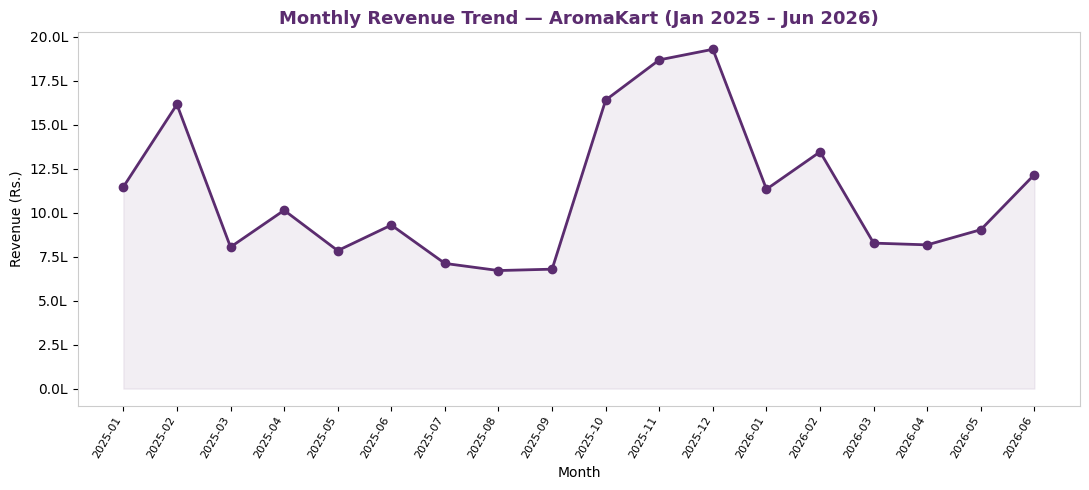

In [7]:
monthly = df.groupby("Month")["Total_Amount"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["Month"], monthly["Total_Amount"], marker="o", color=PURPLE, linewidth=2)
ax.fill_between(range(len(monthly)), monthly["Total_Amount"], color=PURPLE, alpha=0.08)
ax.set_title("Monthly Revenue Trend — AromaKart (Jan 2025 – Jun 2026)", fontsize=13, fontweight="bold", color=PURPLE)
ax.set_ylabel("Revenue (Rs.)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}L"))
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../visuals/01_monthly_revenue_trend.png", dpi=150)
plt.show()

**Insight:** Revenue clearly spikes around Oct–Nov (Diwali) and Dec–Jan (New Year), confirming the seasonal patterns AromaKart's marketing team suspected but never measured.

## 3. Revenue by City

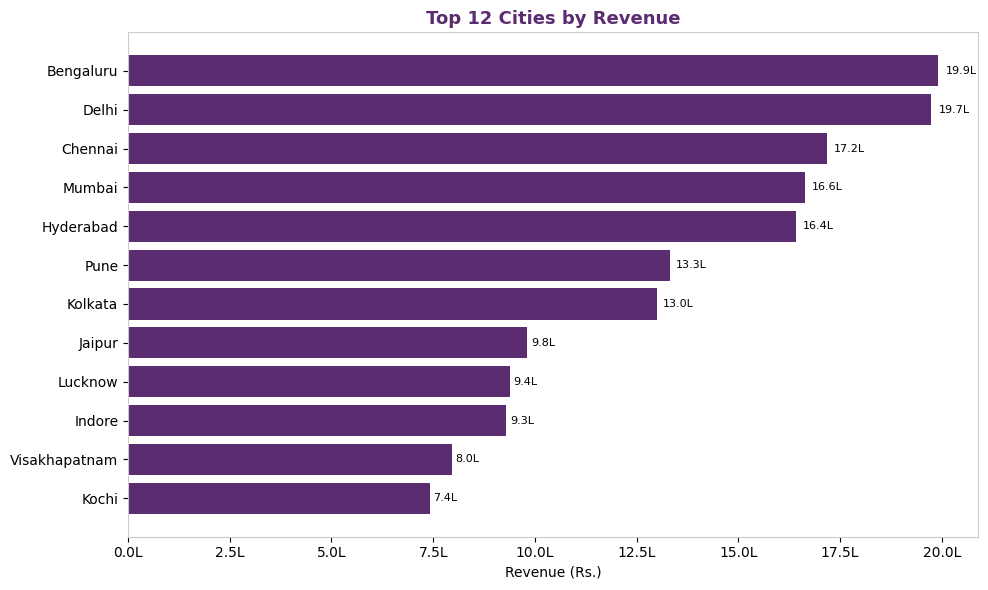

In [8]:
city_rev = df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(city_rev.index[::-1], city_rev.values[::-1], color=PURPLE)
ax.set_title("Top 12 Cities by Revenue", fontsize=13, fontweight="bold", color=PURPLE)
ax.set_xlabel("Revenue (Rs.)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}L"))
for bar in bars:
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width()/1e5:.1f}L", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../visuals/02_revenue_by_city.png", dpi=150)
plt.show()

## 4. Brand Revenue vs. Order Volume\nThis chart tests the hypothesis that premium brands sell less often but at a higher price point, while budget brands drive volume.

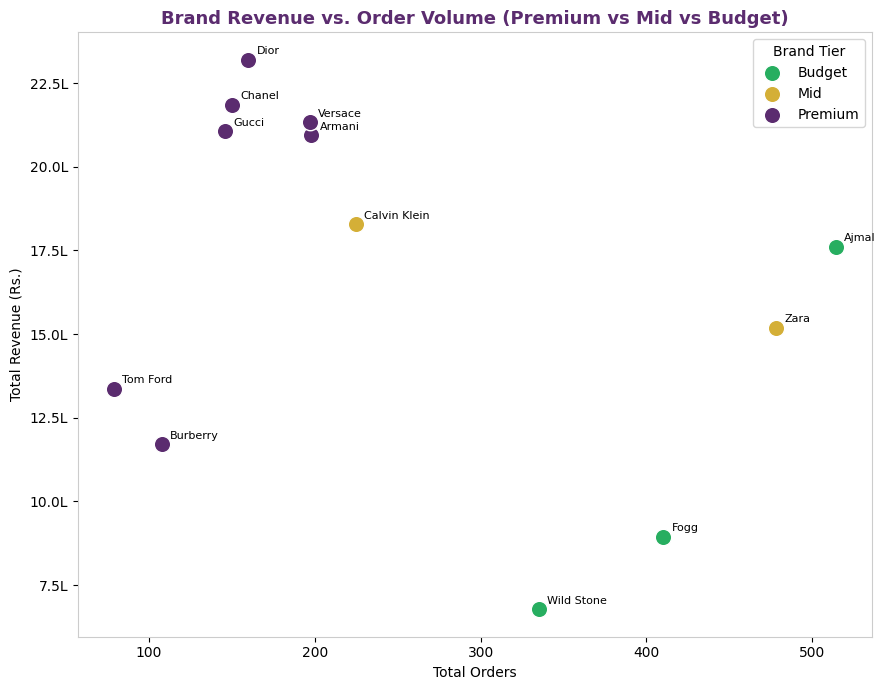

In [9]:
brand_stats = df.groupby(["Brand", "Brand_Tier"]).agg(
    revenue=("Total_Amount", "sum"), orders=("Order_ID", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(9, 7))
tier_colors = {"Premium": "#5B2C6F", "Mid": "#D4AF37", "Budget": "#27AE60"}
for tier, grp in brand_stats.groupby("Brand_Tier"):
    ax.scatter(grp["orders"], grp["revenue"], s=140, color=tier_colors[tier], label=tier, edgecolor="white", linewidth=1)
    for _, row in grp.iterrows():
        ax.annotate(row["Brand"], (row["orders"], row["revenue"]), fontsize=8,
                    xytext=(6, 4), textcoords="offset points")
ax.set_title("Brand Revenue vs. Order Volume (Premium vs Mid vs Budget)", fontsize=13, fontweight="bold", color=PURPLE)
ax.set_xlabel("Total Orders")
ax.set_ylabel("Total Revenue (Rs.)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}L"))
ax.legend(title="Brand Tier")
plt.tight_layout()
plt.savefig("../visuals/03_brand_revenue_vs_volume.png", dpi=150)
plt.show()

## 5. Delivery Outcomes by Brand Tier\nTesting whether premium perfumes really do get returned more often.

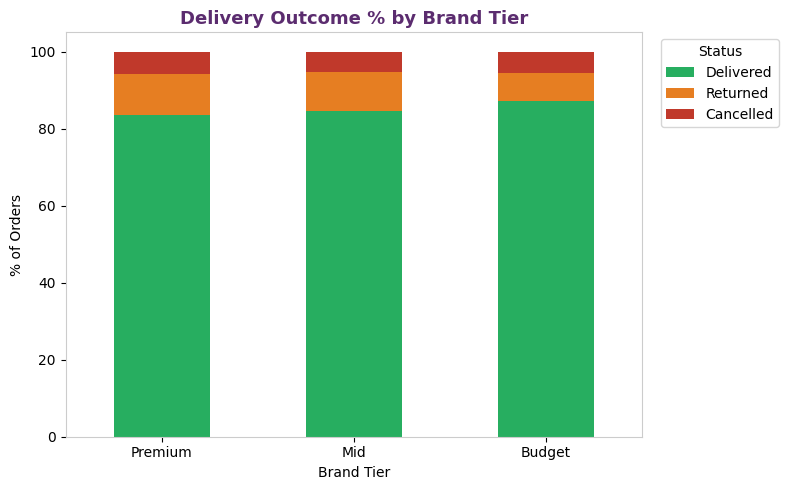

Delivery_Status,Delivered,Returned,Cancelled
Brand_Tier,,,
Premium,83.6,10.5,5.9
Mid,84.5,10.2,5.3
Budget,87.3,7.2,5.5


In [10]:
status_tier = pd.crosstab(df["Brand_Tier"], df["Delivery_Status"], normalize="index") * 100
status_tier = status_tier[["Delivered", "Returned", "Cancelled"]].loc[["Premium", "Mid", "Budget"]]

fig, ax = plt.subplots(figsize=(8, 5))
status_tier.plot(kind="bar", stacked=True, ax=ax, color=["#27AE60", "#E67E22", "#C0392B"])
ax.set_title("Delivery Outcome % by Brand Tier", fontsize=13, fontweight="bold", color=PURPLE)
ax.set_ylabel("% of Orders")
ax.set_xlabel("Brand Tier")
plt.xticks(rotation=0)
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../visuals/04_delivery_status_by_tier.png", dpi=150)
plt.show()

status_tier.round(1)

## 6. Payment Method Mix

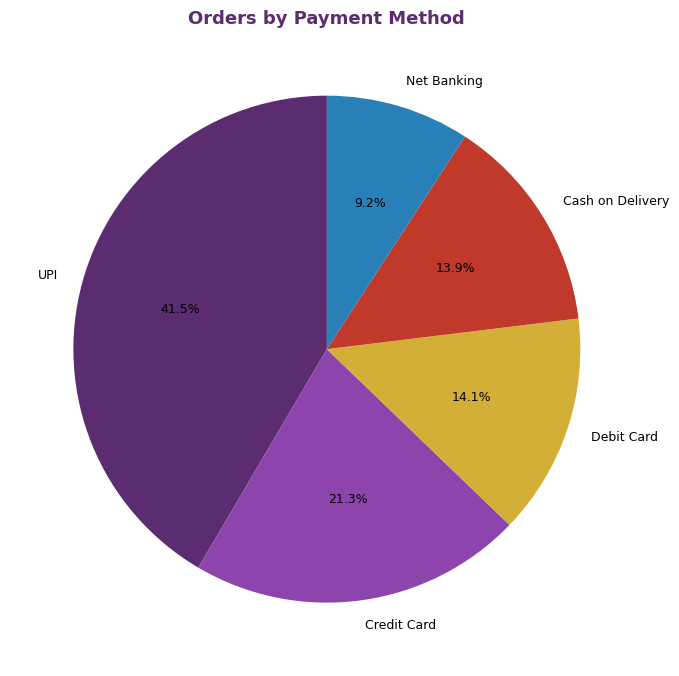

In [11]:
pay_counts = df["Payment_Method"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(pay_counts.values, labels=pay_counts.index, autopct="%1.1f%%",
       colors=PALETTE, startangle=90, textprops={"fontsize": 9})
ax.set_title("Orders by Payment Method", fontsize=13, fontweight="bold", color=PURPLE)
plt.tight_layout()
plt.savefig("../visuals/05_payment_method_mix.png", dpi=150)
plt.show()

## 7. Repeat vs. One-Time Customer Revenue Share

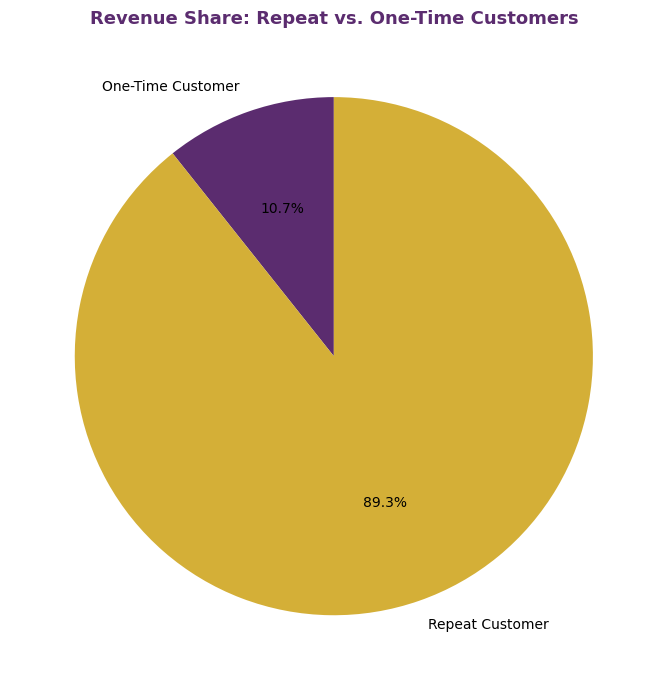

In [12]:
cust_orders = df.groupby("Customer_ID").agg(orders=("Order_ID", "count"), revenue=("Total_Amount", "sum"))
cust_orders["type"] = np.where(cust_orders["orders"] > 1, "Repeat Customer", "One-Time Customer")
rev_share = cust_orders.groupby("type")["revenue"].sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(rev_share.values, labels=rev_share.index, autopct="%1.1f%%",
       colors=[PURPLE, GOLD], startangle=90, textprops={"fontsize": 10})
ax.set_title("Revenue Share: Repeat vs. One-Time Customers", fontsize=13, fontweight="bold", color=PURPLE)
plt.tight_layout()
plt.savefig("../visuals/06_repeat_vs_onetime_revenue.png", dpi=150)
plt.show()

## 8. Key Metrics Summary

In [13]:
print("Total Revenue: Rs.", round(df["Total_Amount"].sum(), 2))
print("Total Orders:", len(df))
print("Average Order Value: Rs.", round(df["Total_Amount"].mean(), 2))
print("Unique Customers:", df["Customer_ID"].nunique())
print("Return Rate: {:.1f}%".format(100 * (df["Delivery_Status"] == "Returned").mean()))
print("Cancellation Rate: {:.1f}%".format(100 * (df["Delivery_Status"] == "Cancelled").mean()))
print("Top City:", df.groupby("City")["Total_Amount"].sum().idxmax())
print("Top Brand:", df.groupby("Brand")["Total_Amount"].sum().idxmax())

Total Revenue: Rs. 20027271.2
Total Orders: 3000
Average Order Value: Rs. 6675.76
Unique Customers: 723
Return Rate: 9.1%
Cancellation Rate: 5.6%
Top City: Bengaluru
Top Brand: Dior


## 9. Summary of Findings

- Revenue is strongly seasonal, peaking around Diwali (Oct–Nov) and New Year (Dec–Jan).
- Metro cities (Bengaluru, Mumbai, Delhi) lead in total revenue.
- Premium brands generate high revenue-per-order but far fewer orders than budget brands —
  a classic volume-vs-margin trade-off.
- Premium brands show a visibly higher return rate than budget brands.
- UPI dominates the payment mix, consistent with broader Indian e-commerce trends.
- A meaningful share of revenue comes from repeat customers, supporting a loyalty-program
  business case.
